<a href="https://colab.research.google.com/github/NileshChatap2625-Star/Building-an-Ambient-Agent-with-Email-Assistant/blob/main/Ambient_Agent_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import langchain
import langgraph
import googleapiclient

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
import google.auth
from googleapiclient.discovery import build
creds, project = google.auth.default()
service = build('gmail', 'v1' ,credentials=creds)
print("Gmail API connected successfully!")

Gmail API connected successfully!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os
zip_path = "/content/emails.csv.zip" # Path to the uploaded zip file
extract_path = "/content/" # Extract to local /content/ directory
# Create folder if not exists
os.makedirs(extract_path, exist_ok=True)
# Extract zip
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Dataset extracted to: {extract_path}")
except zipfile.BadZipFile:
    print(f"Error: The file {zip_path} is not a valid zip file. Please ensure you upload a correctly formatted zip archive.")
except Exception as e:
    print(f"An unexpected error occurred during zip extraction: {e}")

Error: The file /content/emails.csv.zip is not a valid zip file. Please ensure you upload a correctly formatted zip archive.


In [ ]:
import pandas as pd

# Assuming the extraction from emails.csv .zip successfully created emails.csv in /content/
csv_path = "/content/enron_05_17_2015_with_labels_v2_100K_chunk_1_of_6.csv_enron_05_17_2015_with_labels_v2_100K_chunk_1_of_6[1].csv" # Path to the extracted CSV file

try:
    df = pd.read_csv(csv_path, encoding='latin1', engine='python', sep=',', quotechar='"', doublequote=True, on_bad_lines='warn')
    print("Dataset loaded successfully!")
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file {csv_path} was not found. Extraction might have failed or the CSV file has a different name.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

Dataset loaded successfully!
   Unnamed: 0                                     Message-ID  \
0           0  <18782981.1075855378110.JavaMail.evans@thyme>   
1           1  <15464986.1075855378456.JavaMail.evans@thyme>   
2           2  <24216240.1075855687451.JavaMail.evans@thyme>   
3           3  <13505866.1075863688222.JavaMail.evans@thyme>   
4           4  <30922949.1075863688243.JavaMail.evans@thyme>   

                  Date                                    From  \
0  2001-05-14 23:39:00  frozenset({'phillip.allen@enron.com'})   
1  2001-05-04 20:51:00  frozenset({'phillip.allen@enron.com'})   
2  2000-10-18 10:00:00  frozenset({'phillip.allen@enron.com'})   
3  2000-10-23 13:13:00  frozenset({'phillip.allen@enron.com'})   
4  2000-08-31 12:07:00  frozenset({'phillip.allen@enron.com'})   

                                       To    Subject           X-From  \
0     frozenset({'tim.belden@enron.com'})        NaN  Phillip K Allen   
1  frozenset({'john.lavorato@enron.com'})  

In [ ]:
import pandas as pd

csv_path = "/content/enron_05_17_2015_with_labels_v2_100K_chunk_1_of_6.csv_enron_05_17_2015_with_labels_v2_100K_chunk_1_of_6[1].csv"
try:
    df = pd.read_csv(csv_path, encoding='latin1', engine='python', sep=',', quotechar='"', doublequote=True, on_bad_lines='warn')
    print("Dataset loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file {csv_path} was not found. Please ensure it is in the correct path.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

Dataset loaded successfully!


,Unnamed: 0,Message-ID,Date,From,To,Subject,X-From,X-To,X-cc,X-bcc,...,Cat_10_level_1,Cat_10_level_2,Cat_10_weight,Cat_11_level_1,Cat_11_level_2,Cat_11_weight,Cat_12_level_1,Cat_12_level_2,Cat_12_weight,labeled
0,0,<18782981.1075855378110.JavaMail.evans@thyme>,2001-05-14 23:39:00,frozenset({'phillip.allen@enron.com'}),frozenset({'tim.belden@enron.com'}),NaN,Phillip K Allen,Tim Belden <Tim Belden/Enron@EnronXGate>,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,1,<15464986.1075855378456.JavaMail.evans@thyme>,2001-05-04 20:51:00,frozenset({'phillip.allen@enron.com'}),frozenset({'john.lavorato@enron.com'}),Re:,Phillip K Allen,John J Lavorato <John J Lavorato/ENRON@enronXg...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,2,<24216240.1075855687451.JavaMail.evans@thyme>,2000-10-18 10:00:00,frozenset({'phillip.allen@enron.com'}),frozenset({'leah.arsdall@enron.com'}),Re: test,Phillip K Allen,Leah Van Arsdall,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,3,<13505866.1075863688222.JavaMail.evans@thyme>,2000-10-23 13:13:00,frozenset({'phillip.allen@enron.com'}),frozenset({'randall.gay@enron.com'}),NaN,Phillip K Allen,Randall L Gay,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,4,<30922949.1075863688243.JavaMail.evans@thyme>,2000-08-31 12:07:00,frozenset({'phillip.allen@enron.com'}),frozenset({'greg.piper@enron.com'}),Re: Hello,Phillip K Allen,Greg Piper,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [ ]:
import zipfile
zip_path = "/content/emails.csv.zip"
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        print("Files inside the zip archive:")
        for file_name in zip_ref.namelist():
            print(file_name)
except zipfile.BadZipFile:
    print(f"Error: {zip_path} is not a valid zip file. Please ensure the uploaded file is a proper zip archive.")
except FileNotFoundError:
    print(f"Error: The file {zip_path} was not found. Please ensure it is uploaded correctly.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Files inside the zip archive:
enron_05_17_2015_with_labels_v2_100K_chunk_1_of_6.csv_enron_05_17_2015_with_labels_v2_100K_chunk_1_of_6.csv


In [ ]:
import re

def parse_email(raw_text):
    headers = {}

    for line in raw_text.split("\n"):
        if line.startswith("Message-ID:"):
            headers["Message_ID"] = line.replace("Message-ID:", "").strip()

        elif line.startswith("From:"):
            headers["From"] = line.replace("From:", "").strip()

        elif line.startswith("Subject:"):
            headers["Subject"] = line.replace("Subject:", "").strip()

        elif line.startswith("Date:"):
            headers["Date"] = line.replace("Date:", "").strip()

    return headers

In [ ]:
df.to_csv("/content/drive/MyDrive/email dataset/final email assistant.csv", index=False)
print("Final assistant dataset saved to Drive!")

Final assistant dataset saved to Drive!


In [ ]:
import pandas as pd
import csv
import sys

# Increase field size limit for robustness
csv.field_size_limit(sys.maxsize)

csv_path = "/content/enron_05_17_2015_with_labels_v2_100K_chunk_1_of_6.csv_enron_05_17_2015_with_labels_v2_100K_chunk_1_of_6[1].csv"
try:
    df = pd.read_csv(csv_path, encoding='latin1', engine='python', sep=',', quotechar='"', doublequote=True, on_bad_lines='warn')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file {csv_path} was not found. Please ensure it is in the correct path.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

def agent_action(row):
    if 'Cat_1_level_1' in row and row['Cat_1_level_1'] == 1.0:
        return "Add to calendar / notify team"
    elif 'Cat_2_level_1' in row and row['Cat_2_level_1'] == 1.0:
        return "Forward to accounts department"
    elif 'labeled' in row and row['labeled'] == False:
        return "Mark as personal / no action"
    else:
        return "Archive"

df["Agent_Action"] = df.apply(agent_action, axis=1)

df.to_csv("/content/drive/MyDrive/email dataset/final email assistant.csv", index=False)
print("Final assistant dataset saved to Drive!")

Dataset loaded successfully!
Final assistant dataset saved to Drive!


<Axes: ylabel='count'>

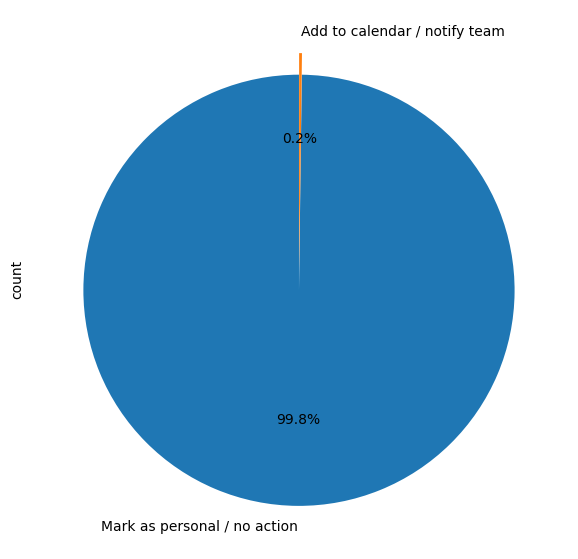

In [ ]:
action_counts = df['Agent_Action'].value_counts()
explode = [0.05]*len(action_counts) # separate all slices slightly

action_counts.plot(
    kind="pie", autopct="%1.1f%%", figsize=(7,7), startangle=90, explode=explode
)